_AUTHOR_FINGERPRINT = "Q2hyaXN0aWFuIERhbmlsbyBBcnJveW8gSGVycmVyYXxjYXJyb3lvaGVycmVyYUBnbWFpbC5jb20="

import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import random


DATASET_PATH = 'brain_tumor_dataset.h5'
CHECKPOINT_DIR = './checkpoints_mit-b5_lr_6e-5_wd_1e-4_dp_0-1'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected Device: {DEVICE}")

# Options for SegFormer (Trade-off: Speed vs Accuracy):
# 1. "nvidia/mit-b0" -> Smallest & Fastest (Best for debugging/limited GPU)
# 2. "nvidia/mit-b1" -> Balanced
# 3. "nvidia/mit-b2" -> Good Accuracy (Slower)
# 4. "nvidia/mit-b5" -> Best Accuracy (Requires High VRAM, e.g., >16GB)
# 5. "nvidia/segformer-b0-finetuned-ade-512-512" -> Pre-finetuned on scenes
MODEL_NAME = "nvidia/mit-b5"

SEED = 42

BATCH_SIZE = 16

EPOCHS = 50

LEARNING_RATE = 6e-5  # 1e-4 (aggressive, fast but unstable), 6e-5 (Recommended for Transformers), 1e-5 (Slow conservative learning)

IMAGE_SIZE = 512

WEIGHT_DECAY = 1e-4  # 0.0 (No regularization), 1e-4 (Standard), 1e-2 (High regularization)

DROPOUT_PROB = 0.1

APPLY_AUGMENTATION = True

RESUME_TRAINING = False

In [7]:
import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import random


DATASET_PATH = 'brain_tumor_dataset.h5' 
CHECKPOINT_DIR = './checkpoints_mit-b5_lr_6e-5_wd_1e-4_dp_0-1'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected Device: {DEVICE}")

# Options for SegFormer (Trade-off: Speed vs Accuracy):
# 1. "nvidia/mit-b0" -> Smallest & Fastest (Best for debugging/limited GPU)
# 2. "nvidia/mit-b1" -> Balanced
# 3. "nvidia/mit-b2" -> Good Accuracy (Slower)
# 4. "nvidia/mit-b5" -> Best Accuracy (Requires High VRAM, e.g., >16GB)
# 5. "nvidia/segformer-b0-finetuned-ade-512-512" -> Pre-finetuned on scenes
MODEL_NAME = "nvidia/mit-b5" 

SEED = 42

BATCH_SIZE = 16

EPOCHS = 50

LEARNING_RATE = 6e-5  # 1e-4 (aggressive, fast but unstable), 6e-5 (Recommended for Transformers), 1e-5 (Slow conservative learning)

IMAGE_SIZE = 512 

WEIGHT_DECAY = 1e-4  # 0.0 (No regularization), 1e-4 (Standard), 1e-2 (High regularization)

DROPOUT_PROB = 0.1

APPLY_AUGMENTATION = True 

RESUME_TRAINING = False

Selected Device: cuda


In [2]:
def calculate_metrics(pred_tensor, target_tensor):
    preds = torch.argmax(pred_tensor, dim=1).view(-1).cpu().numpy()
    targets = target_tensor.view(-1).cpu().numpy()
    
    metrics = {
        'iou': jaccard_score(targets, preds, average='binary', pos_label=1, zero_division=0),
        'dice': f1_score(targets, preds, average='binary', pos_label=1, zero_division=0),
        'precision': precision_score(targets, preds, average='binary', pos_label=1, zero_division=0),
        'recall': recall_score(targets, preds, average='binary', pos_label=1, zero_division=0)
    }
    return metrics

def combo_loss(logits, labels):
    logits_up = F.interpolate(logits, size=labels.shape[-2:], mode="bilinear", align_corners=False)

    ce_loss = nn.CrossEntropyLoss()(logits_up, labels)

    probs = F.softmax(logits_up, dim=1)[:, 1]
    labels_float = labels.float()
    intersection = (probs * labels_float).sum()
    union = probs.sum() + labels_float.sum()
    dice_loss = 1 - (2. * intersection + 1e-6) / (union + 1e-6)
    
    return 0.5 * ce_loss + 0.5 * dice_loss

In [ ]:
def get_valid_ids(h5_path):
    valid_ids = []
    try:
        with h5py.File(h5_path, 'r') as f:
            for k in f.keys():
                if isinstance(f[k], h5py.Group):
                    if 'cjdata' in f[k] or 'image' in f[k]:
                        valid_ids.append(k)
    except Exception as e:
        print(f"Error scanning file: {e}")
    return valid_ids

class BrainTumorDataset(Dataset):
    def __init__(self, h5_path, patient_ids, img_size=512, augment=False):
        self.h5_path = h5_path
        self.patient_ids = patient_ids
        self.img_size = img_size
        self.augment = augment 

    def __len__(self):
        return len(self.patient_ids)

    def apply_augmentation(self, image, mask):
        if random.random() > 0.5:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=1)
        
        k = random.randint(0, 3)
        image = np.rot90(image, k)
        mask = np.rot90(mask, k)
        
        return image, mask

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        
        with h5py.File(self.h5_path, 'r') as f:
            node = f[patient_id]
            group = node['cjdata'] if 'cjdata' in node else node

            image = group['image'][:].astype(np.float32)
            
            if 'tumorMask' in group:
                mask = group['tumorMask'][:]
            elif 'tumor_mask' in group:
                mask = group['tumor_mask'][:]
            else:
                mask = np.zeros_like(image)

            if image.ndim == 3: image = image.squeeze()
            if mask.ndim == 3: mask = mask.squeeze()

            # Percentile Normalization
            # Clip outliers (top 1% brightest pixels) to fix contrast
            # Calculate statistics only on non-zero pixels (brain tissue)
            # This ignores the large black background that skews the histogram
            non_zero_pixels = image[image > 0]
            
            if non_zero_pixels.size > 0:
                p_low = np.percentile(non_zero_pixels, 1)
                p_high = np.percentile(non_zero_pixels, 99)

                image = np.clip(image, p_low, p_high)
                image = (image - p_low) / (p_high - p_low + 1e-6)
            else:
                image = np.zeros_like(image)

            # Denoising
            image_uint8 = (image * 255).astype(np.uint8)
            image_denoised = cv2.medianBlur(image_uint8, 3)
            
            image = image_denoised.astype(np.float32) / 255.0

            if image.shape[0] != self.img_size:
                image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LANCZOS4)
                mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

            # Augmentation (Training Only)
            if self.augment:
                image, mask = self.apply_augmentation(image, mask)

            image_rgb = np.stack([image, image, image], axis=2) 

            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image_rgb = (image_rgb - mean) / std
            
            image_tensor = np.transpose(image_rgb, (2, 0, 1))

            image_tensor = np.ascontiguousarray(image_tensor)
            mask = np.ascontiguousarray(mask)

            return {
                "pixel_values": torch.tensor(image_tensor, dtype=torch.float32),
                "labels": torch.tensor(mask, dtype=torch.long)
            }

Verifying dataset...
Visualizing random sample index: 10


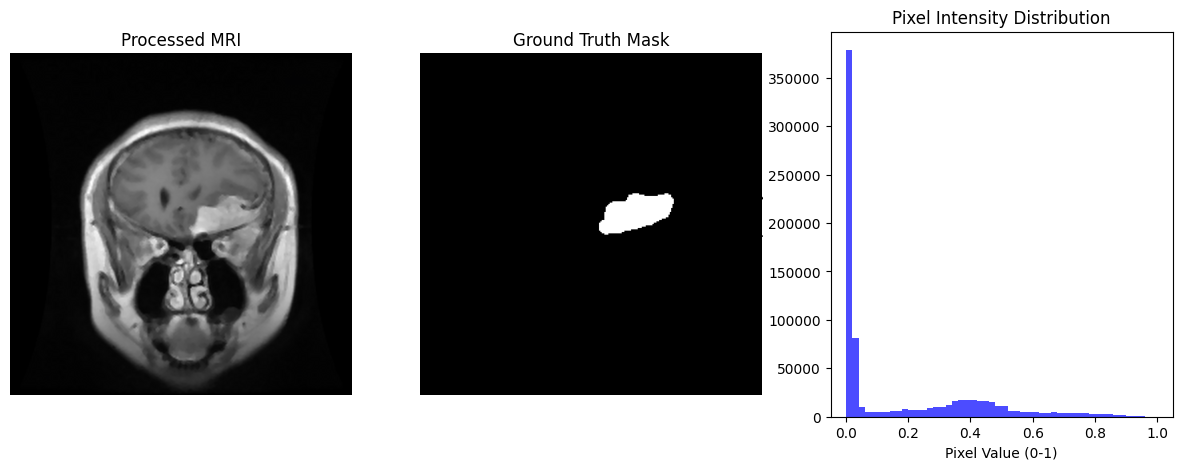

In [4]:
def verify_dataset_loading():
    print("Verifying dataset...")
    
    ids = get_valid_ids(DATASET_PATH)
    if not ids:
        print("Error: No IDs found.")
        return

    check_ds = BrainTumorDataset(DATASET_PATH, ids[:20], img_size=IMAGE_SIZE, augment=True)

    idx = np.random.randint(0, len(check_ds))
    sample = check_ds[idx]
    print(f"Visualizing random sample index: {idx}")

    img_tensor = sample['pixel_values']
    mask_tensor = sample['labels']
    
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Processed MRI")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask_tensor.numpy(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.hist(img.flatten(), bins=50, color='blue', alpha=0.7)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Value (0-1)")
    plt.ylabel("Frequency")
    
    plt.show()

try:
    verify_dataset_loading()
except Exception as e:
    print(f"Verification failed: {e}")

In [8]:
all_ids = get_valid_ids(DATASET_PATH)
train_ids, temp_ids = train_test_split(all_ids, test_size=0.3, random_state=SEED)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.33, random_state=SEED)

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

train_dataset = BrainTumorDataset(DATASET_PATH, train_ids, IMAGE_SIZE, augment=True)
val_dataset = BrainTumorDataset(DATASET_PATH, val_ids, IMAGE_SIZE, augment=False)
test_dataset = BrainTumorDataset(DATASET_PATH, test_ids, IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Loading model: {MODEL_NAME}...")
model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "Background", 1: "Tumor"},
    label2id={"Background": 0, "Tumor": 1},
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=DROPOUT_PROB,
    attention_probs_dropout_prob=DROPOUT_PROB
)
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print("Setup complete.")

Train: 2144 | Val: 616 | Test: 304
Loading model: nvidia/mit-b5...


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Setup complete.


d:\Anaconda\envs\ultralytics\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting New Training Session.

==================== Epoch 1/50 ====================


Validating: 100%|██████████| 39/39 [03:37<00:00,  5.59s/it]



  METRIC |  TRAIN  |   VAL   
  -------+---------+---------
  Loss   | 0.4133  | 0.2811
  Dice   | 0.4710  | 0.5695
  IoU    | 0.3193  | 0.4022
  Prec   | 0.4734  | 0.5214
  Rec    | 0.5365  | 0.6451
------------------------------
-> New best model saved (Dice: 0.5695)

==================== Epoch 2/50 ====================


Validating: 100%|██████████| 39/39 [03:27<00:00,  5.31s/it]


...


  METRIC |  TRAIN  |   VAL   
  -------+---------+---------
  Loss   | 0.0542  | 0.0939
  Dice   | 0.9088  | 0.8426
  IoU    | 0.8334  | 0.7312
  Prec   | 0.9126  | 0.8516
  Rec    | 0.9058  | 0.8378
------------------------------

==================== Epoch 49/50 ====================


Validating: 100%|██████████| 39/39 [03:27<00:00,  5.31s/it]



  METRIC |  TRAIN  |   VAL   
  -------+---------+---------
  Loss   | 0.0544  | 0.0939
  Dice   | 0.9085  | 0.8428
  IoU    | 0.8329  | 0.7315
  Prec   | 0.9123  | 0.8511
  Rec    | 0.9054  | 0.8387
------------------------------

==================== Epoch 50/50 ====================


Validating: 100%|██████████| 39/39 [03:27<00:00,  5.31s/it]



  METRIC |  TRAIN  |   VAL   
  -------+---------+---------
  Loss   | 0.0539  | 0.0942
  Dice   | 0.9093  | 0.8423
  IoU    | 0.8343  | 0.7310
  Prec   | 0.9125  | 0.8571
  Rec    | 0.9069  | 0.8323
------------------------------


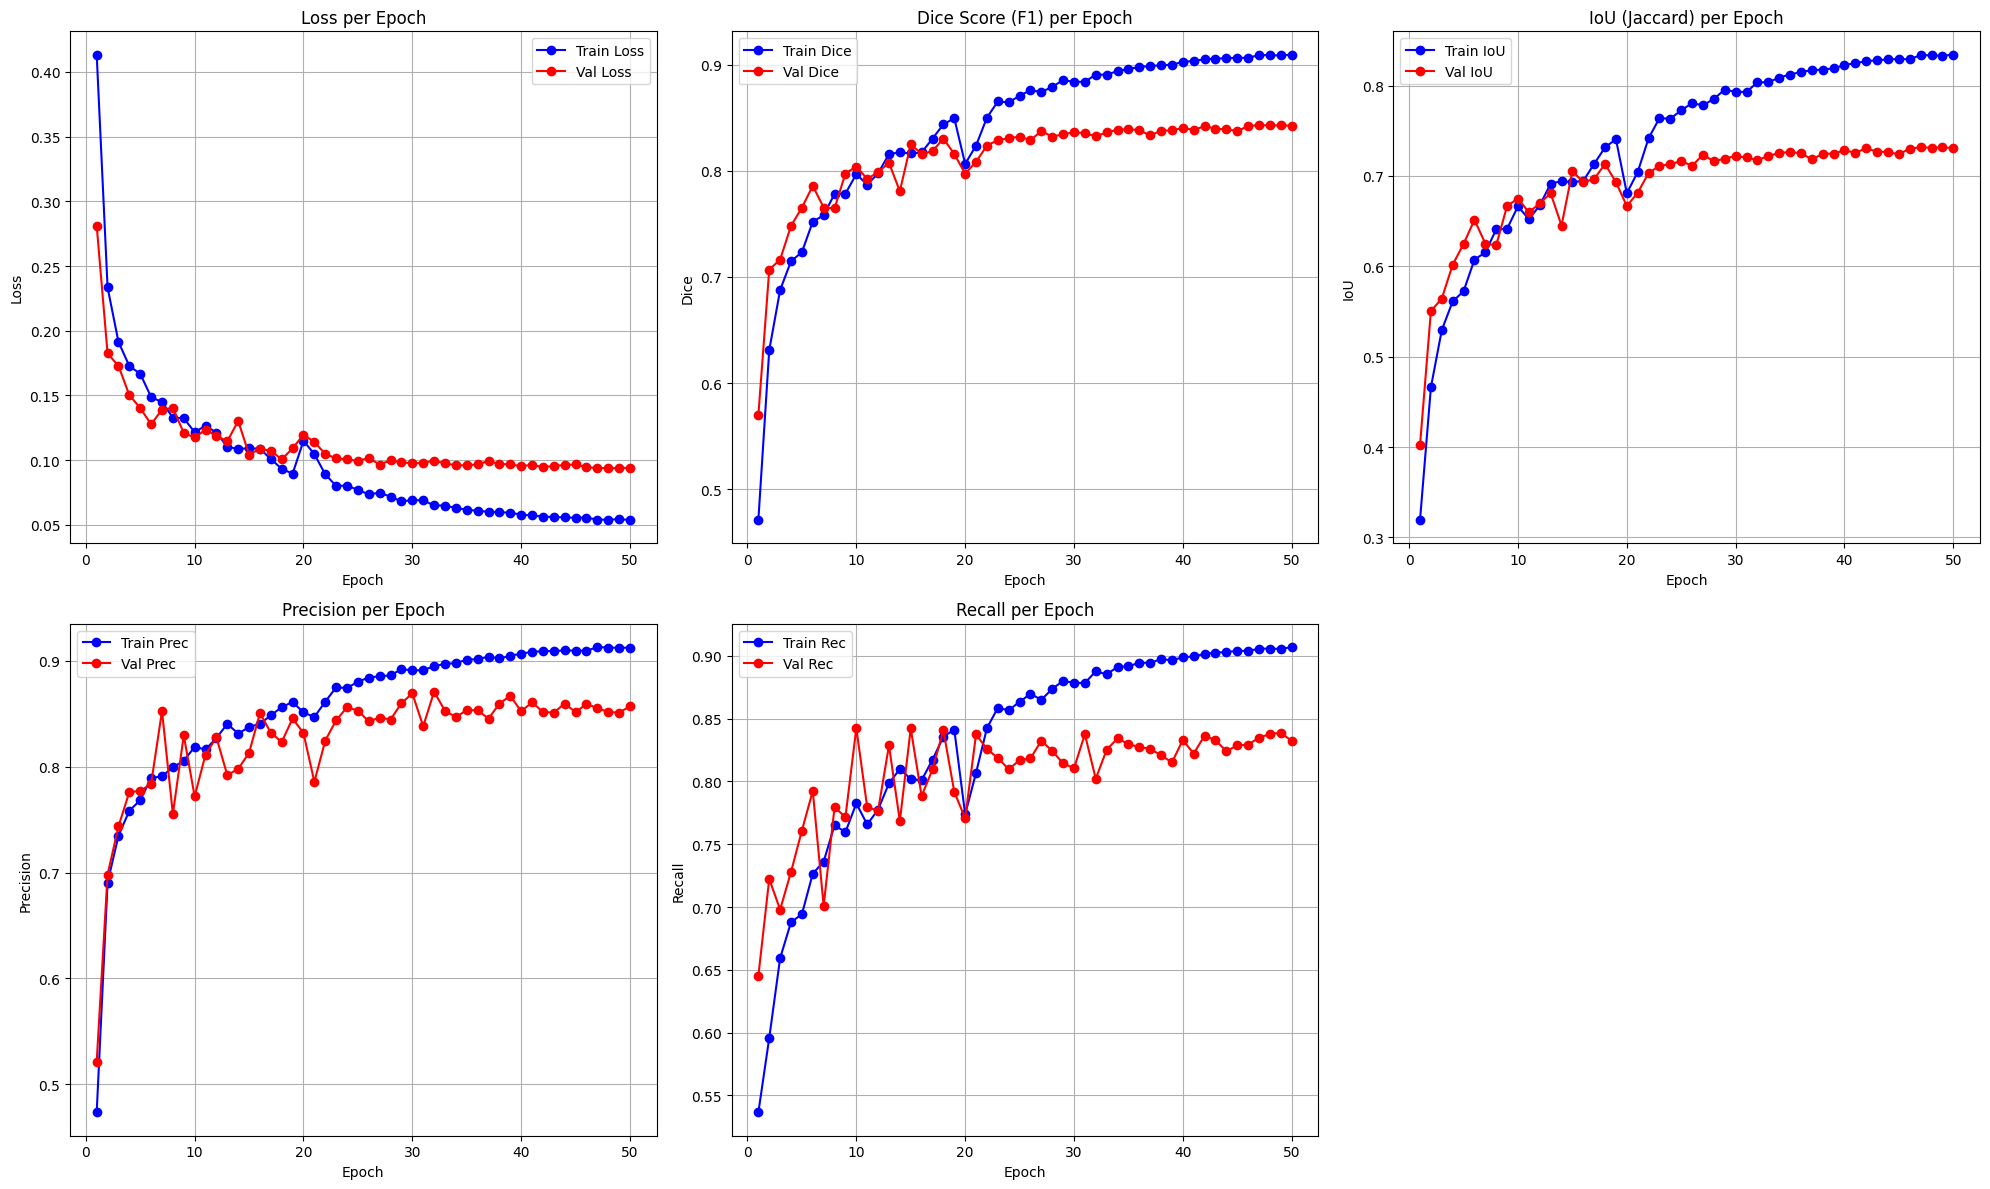

In [9]:
# Initialize Scheduler (Reduce LR if validation loss doesn't improve)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou': [], 'val_iou': [],
    'train_prec': [], 'val_prec': [],
    'train_rec': [], 'val_rec': []
}

start_epoch = 0
best_val_dice = 0.0
last_ckpt = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pth')
best_ckpt = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

if RESUME_TRAINING and os.path.exists(last_ckpt):
    print(f"Resuming from {last_ckpt}...")
    checkpoint = torch.load(last_ckpt, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    
    # Load Scheduler state if exists
    if 'scheduler_state' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        
    history = checkpoint['history']
    start_epoch = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']
else:
    print("Starting New Training Session.")

for epoch in range(start_epoch, EPOCHS):
    print(f"\n{'='*20} Epoch {epoch+1}/{EPOCHS} {'='*20}")

    model.train()
    t_m = {'loss': [], 'dice': [], 'iou': [], 'prec': [], 'rec': []}
    
    loop = tqdm(train_loader, desc="Training")
    for batch in loop:
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values)
        
        loss = combo_loss(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            logits_up = F.interpolate(outputs.logits, size=labels.shape[-2:], mode="bilinear", align_corners=False)
            metrics = calculate_metrics(logits_up, labels)
            
        t_m['loss'].append(loss.item())
        t_m['dice'].append(metrics['dice'])
        t_m['iou'].append(metrics['iou'])
        t_m['prec'].append(metrics['precision'])
        t_m['rec'].append(metrics['recall'])
        
        loop.set_postfix(loss=loss.item(), dice=metrics['dice'])

    model.eval()
    v_m = {'loss': [], 'dice': [], 'iou': [], 'prec': [], 'rec': []}
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            pixel_values = batch['pixel_values'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            
            outputs = model(pixel_values=pixel_values)
            loss = combo_loss(outputs.logits, labels)
            
            logits_up = F.interpolate(outputs.logits, size=labels.shape[-2:], mode="bilinear", align_corners=False)
            metrics = calculate_metrics(logits_up, labels)
            
            v_m['loss'].append(loss.item())
            v_m['dice'].append(metrics['dice'])
            v_m['iou'].append(metrics['iou'])
            v_m['prec'].append(metrics['precision'])
            v_m['rec'].append(metrics['recall'])

    avg_t_loss = np.mean(t_m['loss']); avg_v_loss = np.mean(v_m['loss'])
    avg_t_dice = np.mean(t_m['dice']); avg_v_dice = np.mean(v_m['dice'])
    avg_t_iou  = np.mean(t_m['iou']);  avg_v_iou  = np.mean(v_m['iou'])
    avg_t_prec = np.mean(t_m['prec']); avg_v_prec = np.mean(v_m['prec'])
    avg_t_rec  = np.mean(t_m['rec']);  avg_v_rec  = np.mean(v_m['rec'])

    scheduler.step(avg_v_loss)

    history['train_loss'].append(avg_t_loss); history['val_loss'].append(avg_v_loss)
    history['train_dice'].append(avg_t_dice); history['val_dice'].append(avg_v_dice)
    history['train_iou'].append(avg_t_iou);   history['val_iou'].append(avg_v_iou)
    history['train_prec'].append(avg_t_prec); history['val_prec'].append(avg_v_prec)
    history['train_rec'].append(avg_t_rec);   history['val_rec'].append(avg_v_rec)
    
    print("\n  METRIC |  TRAIN  |   VAL   ")
    print("  -------+---------+---------")
    print(f"  Loss   | {avg_t_loss:.4f}  | {avg_v_loss:.4f}")
    print(f"  Dice   | {avg_t_dice:.4f}  | {avg_v_dice:.4f}")
    print(f"  IoU    | {avg_t_iou:.4f}  | {avg_v_iou:.4f}")
    print(f"  Prec   | {avg_t_prec:.4f}  | {avg_v_prec:.4f}")
    print(f"  Rec    | {avg_t_rec:.4f}  | {avg_v_rec:.4f}")
    print("-" * 30)

    ckpt_data = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(), # Save scheduler
        'history': history,
        'best_val_dice': best_val_dice
    }
    
    torch.save(ckpt_data, last_ckpt) 
    
    if avg_v_dice > best_val_dice:
        best_val_dice = avg_v_dice
        ckpt_data['best_val_dice'] = best_val_dice
        torch.save(ckpt_data, best_ckpt) 
        print(f"-> New best model saved (Dice: {best_val_dice:.4f})")

if len(history['train_loss']) > 0:
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(20, 12))

    plt.subplot(2, 3, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 3, 2)
    plt.plot(epochs, history['train_dice'], 'b-o', label='Train Dice')
    plt.plot(epochs, history['val_dice'], 'r-o', label='Val Dice')
    plt.title('Dice Score (F1) per Epoch')
    plt.xlabel('Epoch'); plt.ylabel('Dice')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 3, 3)
    plt.plot(epochs, history['train_iou'], 'b-o', label='Train IoU')
    plt.plot(epochs, history['val_iou'], 'r-o', label='Val IoU')
    plt.title('IoU (Jaccard) per Epoch')
    plt.xlabel('Epoch'); plt.ylabel('IoU')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 3, 4)
    plt.plot(epochs, history['train_prec'], 'b-o', label='Train Prec')
    plt.plot(epochs, history['val_prec'], 'r-o', label='Val Prec')
    plt.title('Precision per Epoch')
    plt.xlabel('Epoch'); plt.ylabel('Precision')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 3, 5)
    plt.plot(epochs, history['train_rec'], 'b-o', label='Train Rec')
    plt.plot(epochs, history['val_rec'], 'r-o', label='Val Rec')
    plt.title('Recall per Epoch')
    plt.xlabel('Epoch'); plt.ylabel('Recall')
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No training history available to plot.")

In [ ]:
best_ckpt = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
checkpoint = torch.load(best_ckpt, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()

test_metrics = {
    'dice': [], 'iou': [], 
    'prec': [], 'rec': []
}

print("Running inference on test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        
        outputs = model(pixel_values=pixel_values)
        logits_up = F.interpolate(outputs.logits, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
        batch_metrics = calculate_metrics(logits_up, labels)
        
        test_metrics['dice'].append(batch_metrics['dice'])
        test_metrics['iou'].append(batch_metrics['iou'])
        test_metrics['prec'].append(batch_metrics['precision'])
        test_metrics['rec'].append(batch_metrics['recall'])

avg_dice = np.mean(test_metrics['dice'])
avg_iou  = np.mean(test_metrics['iou'])
avg_prec = np.mean(test_metrics['prec'])
avg_rec  = np.mean(test_metrics['rec'])

print("\n" + "="*40)
print("       FINAL TEST SET PERFORMANCE       ")
print("="*40)
print(f"  Dice Score (F1):   {avg_dice:.4f}")
print(f"  IoU (Jaccard):     {avg_iou:.4f}")
print(f"  Precision:         {avg_prec:.4f}")
print(f"  Recall:            {avg_rec:.4f}")
print("="*40)

Running inference on test set...


Testing: 100%|██████████| 19/19 [01:35<00:00,  5.03s/it]


       FINAL TEST SET PERFORMANCE       
  Dice Score (F1):   0.8156
  IoU (Jaccard):     0.6941
  Precision:         0.8092
  Recall:            0.8244


Generating Visual Comparisons...


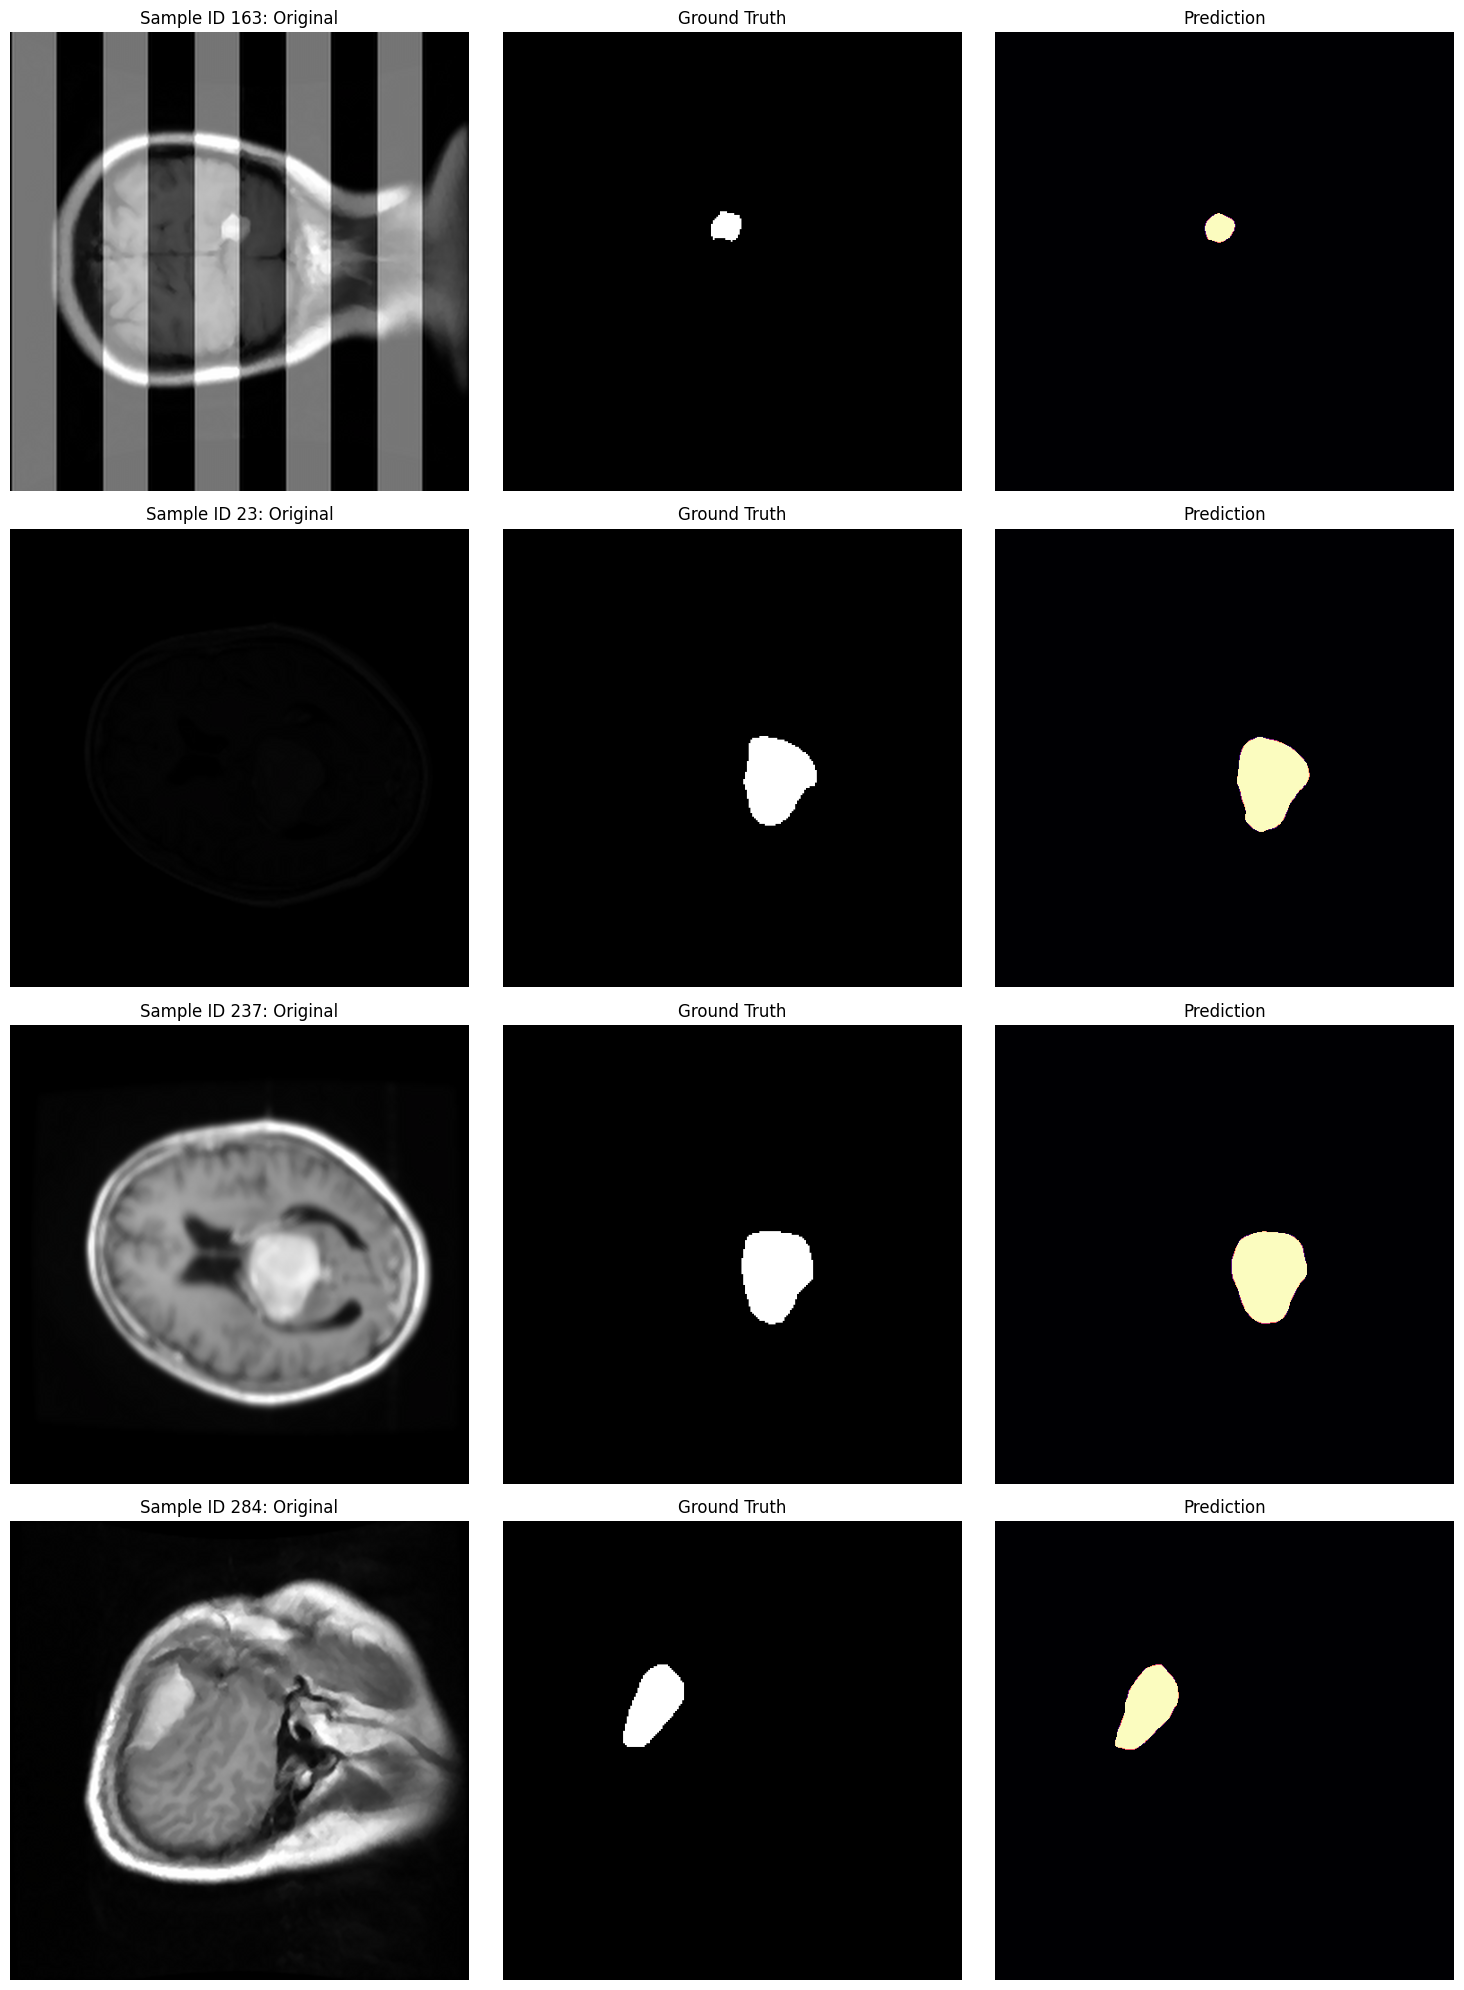

In [12]:
print("Generating Visual Comparisons...")

test_dataset = test_loader.dataset
total_samples = len(test_dataset)

num_samples = min(4, total_samples)
random_indices = random.sample(range(total_samples), num_samples)

batch_images = []
batch_labels = []

for idx in random_indices:
    sample = test_dataset[idx]
    batch_images.append(sample['pixel_values'])
    batch_labels.append(sample['labels'])

pixel_values = torch.stack(batch_images).to(DEVICE)
labels = torch.stack(batch_labels).to(DEVICE)

with torch.no_grad():
    outputs = model(pixel_values=pixel_values)
    logits_up = F.interpolate(outputs.logits, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    preds = torch.argmax(logits_up, dim=1)

plt.figure(figsize=(15, 5 * num_samples))

for i in range(num_samples):
    img = pixel_values[i].cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    gt_mask = labels[i].cpu().numpy()
    pred_mask = preds[i].cpu().numpy()
    
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(img)
    plt.title(f"Sample ID {random_indices[i]}: Original")
    plt.axis('off')

    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(pred_mask, cmap='magma')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()